# This is to deal only with the ID = 48 File for finding NSC

In [2]:
import numpy as np
import pandas, os, astropy, scipy, math
import matplotlib.pyplot as plt
import sklearn
from photutils.aperture import CircularAperture, SkyCircularAperture, aperture_photometry, EllipticalAperture, SkyEllipticalAperture
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.wcs.utils import pixel_to_skycoord
import astropy.io.fits as fits
from reproject import reproject_interp
import img_scale
from mpl_toolkits.axes_grid1 import Divider, Size
from astropy.cosmology import FlatLambdaCDM 
from astropy.wcs.utils import proj_plane_pixel_scales

# how to scatter a circle
plt.scatter(coord, coord, ec(edge color) = 'blue', fc(face color) = 'none, s = large(300 ish))

# select the NSC in the previous graphs
also plot the color with no radius filter and mark the NSC while also changing the limit to -1 to 3 or something like that

In [3]:
# Writing a function to calculate the magnitude difference bewteen the 2 largest objects
def max_mag_diff(magar):
    lstmag = magar.tolist()
    sortedlstmag = sorted(lstmag)
    magdif1 = sortedlstmag[0] - sortedlstmag[1]
    print(" The magnitude difference between the brightest and 2nd brightest object is {}".format(magdif1))

In [4]:
galcen = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/48_SMDG1257009+273155_gal_loc.csv')
galcenx55 = galcen['xc'].values[0]
galceny55 = galcen['yc'].values[0]
cut_cat55 = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/48_SMDG1257009+273155_cut_catalog.csv')
cut_cat55.columns

Index(['Unnamed: 0', 'ext', 'chip', 'xc', 'yc', 'chi', 'snr', 'sharpness',
       'roundness', 'pa', 'crowding', 'objtype', 'F475W_count', 'F475W_sky',
       'F475W_count_rate', 'F475W_count_rate_uncer', 'F475W_mag_vega',
       'F475W_mag_ubvri', 'F475W_mag_uncer', 'F475W_chi', 'F475W_snr',
       'F475W_sharpness', 'F475W_roundness', 'F475W_crowding', 'F475W_flag',
       'F814W_count', 'F814W_sky', 'F814W_count_rate',
       'F814W_count_rate_uncer', 'F814W_mag_vega', 'F814W_mag_ubvri',
       'F814W_mag_uncer', 'F814W_chi', 'F814W_snr', 'F814W_sharpness',
       'F814W_roundness', 'F814W_crowding', 'F814W_flag', 'aper_4', 'aper_8',
       'newconcent'],
      dtype='object')

In [5]:
# Define cuts that we are using(comment out this cell to get the original data)
use_cat = cut_cat55

max_mag = 35.  # Maxmum mag (Telescope cut)
snr_thresh = 3.  # For nearby, 5
# crowd_thresh = 0.5 #[mag], Normal cut  
# sharp_thresh = 0.25 #Normal cut  defraction spikes
# round_thresh = 3.  #Weak constraint (elongated)
flag_thresh = np.array([0, 2])
flag_label = np.array(['Good', 'Edge', 'Bad,Sat-pixel', 'Edge+badpixel'])

## Instrumental VEGAMAG magnitude cut
print(f"Total dolphot catalogue length: {len(use_cat)}")
print(f"Require: mag < {max_mag}")
condition = (use_cat.iloc[:,16] < max_mag) & (use_cat.iloc[:,29] < max_mag)
sub_dolcut_cat = use_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## SNR cut
print(f"Require: S/N > {snr_thresh}.")
condition = (sub_dolcut_cat.iloc[:,20] > snr_thresh) & (sub_dolcut_cat.iloc[:,33] > snr_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Object Type cut
print("Remove sources that are not type point-like.")
condition = (sub_dolcut_cat.iloc[:,11] <= 2)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Photometry quality flag cut
print("Remove sources that have flag= ", flag_thresh, "or", flag_label[flag_thresh])
condition = np.isin(sub_dolcut_cat.iloc[:,24], flag_thresh) & np.isin(sub_dolcut_cat.iloc[:,37], flag_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

cut_cat55 = sub_dolcut_cat 

Total dolphot catalogue length: 59756
Require: mag < 35.0
New catalogue length: 59368
Require: S/N > 3.0.
New catalogue length: 5617
Remove sources that are not type point-like.
New catalogue length: 5491
Remove sources that have flag=  [0 2] or ['Good' 'Bad,Sat-pixel']
New catalogue length: 5413


In [6]:
#creating 2 numpy arrays that hold the xc and yc of each bright object
xcgal55 = cut_cat55['xc'].to_numpy()
ycgal55 = cut_cat55['yc'].to_numpy()
f606mag55 = cut_cat55['F475W_mag_vega'].to_numpy()
f814mag55 = cut_cat55['F814W_mag_vega'].to_numpy()

In [7]:
#calculating the distance from the centre of the galaxy for each bright object
distgal55 = np.sqrt((xcgal55 - galcenx55)**2 + (ycgal55 - galceny55)**2)


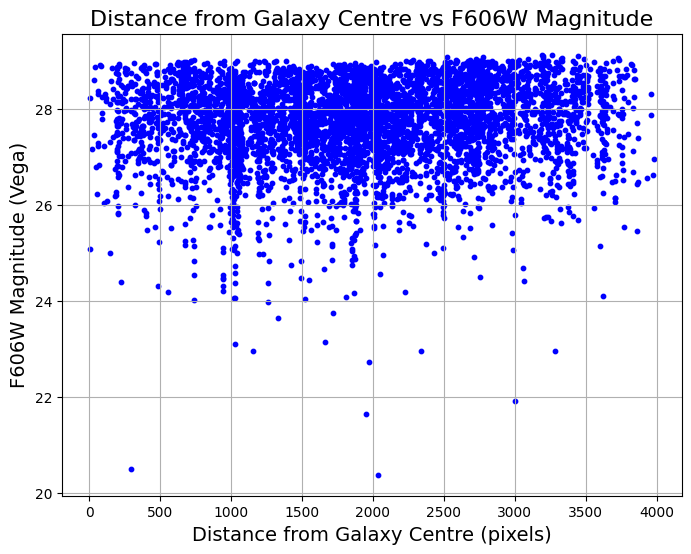

In [8]:
#plotting distance vs magnitude for F606W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

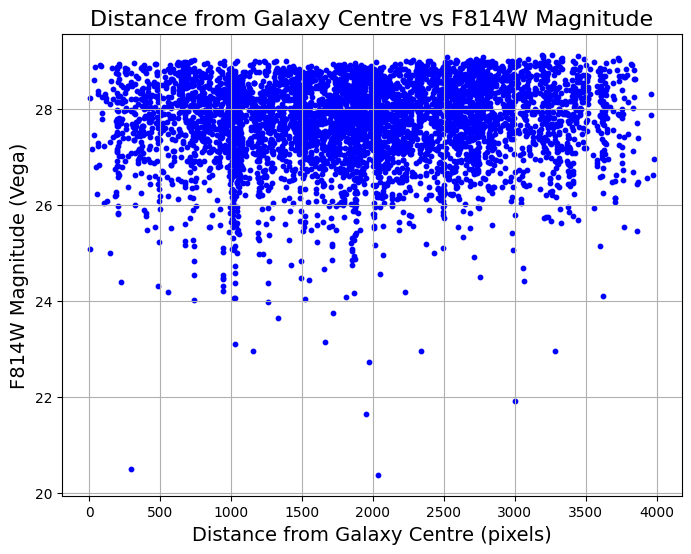

In [9]:
#plotting the distance vs magnitude for F814W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

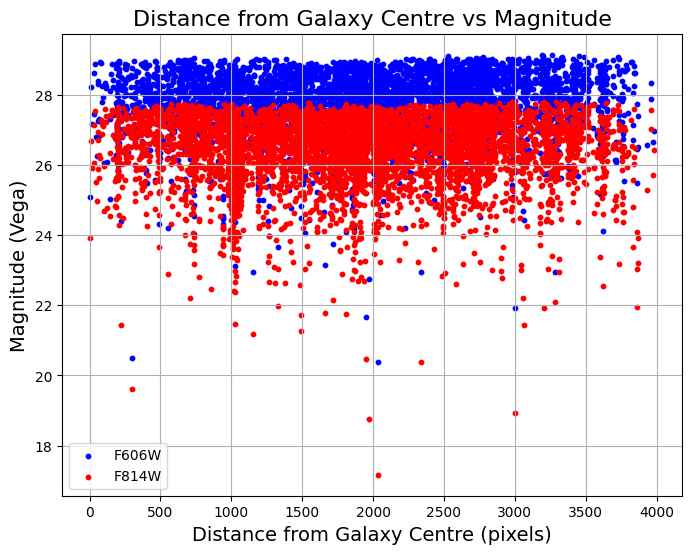

In [10]:
#plotting distance vs magnitude for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal55, f606mag55, color='blue', s=10, label='F606W')
plt.scatter(distgal55, f814mag55, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [11]:
# converting pixel in re(arcsec) to pixels
re_arcsec55 = 5.32

hdul55 = fits.open('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/ID_48_F814/MAST_2026-02-17T2124/MAST_2026-02-17T2124/HST/j9ty90030_drc.fits')
if len(hdul55) > 1:
    hdr55 = hdul55[1].header
else:
    hdr55 = hdul55[0].header
wcs55 = WCS(hdr55)
pixel_scale_degrees55 = proj_plane_pixel_scales(wcs55)
scale_arcsec_per_pixel55 = pixel_scale_degrees55[0] * 3600
scale_pixel_per_arcsec55 = 1 / scale_arcsec_per_pixel55
re_pixels55 = re_arcsec55 * scale_pixel_per_arcsec55
print(re_pixels55)

106.40000000000168


In [12]:
#refining the bright object list to only include objects within re and finding the colour of the objects
distgal_re55 = distgal55[distgal55 <= re_pixels55]
f606mag_re55 = f606mag55[distgal55 <= re_pixels55]
f814mag_re55 = f814mag55[distgal55 <= re_pixels55]
color55 = f606mag_re55 - f814mag_re55 

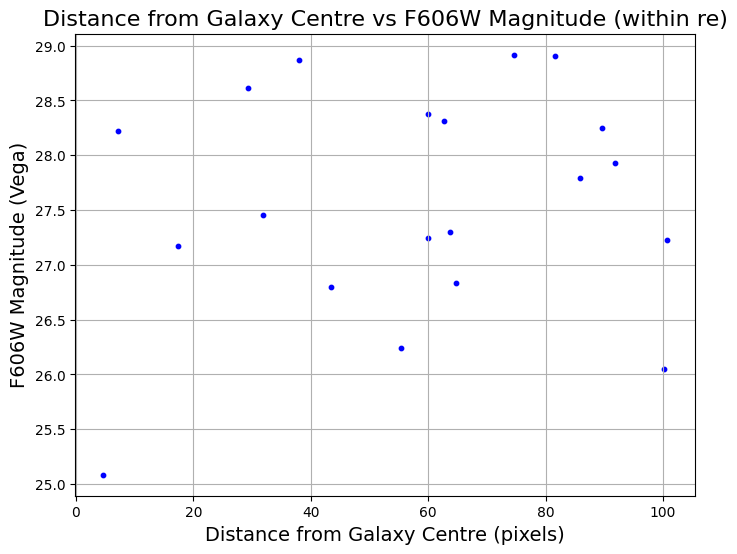

In [13]:
#plotting distance vs magnitude for f606w in re 
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f606mag_re55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()  

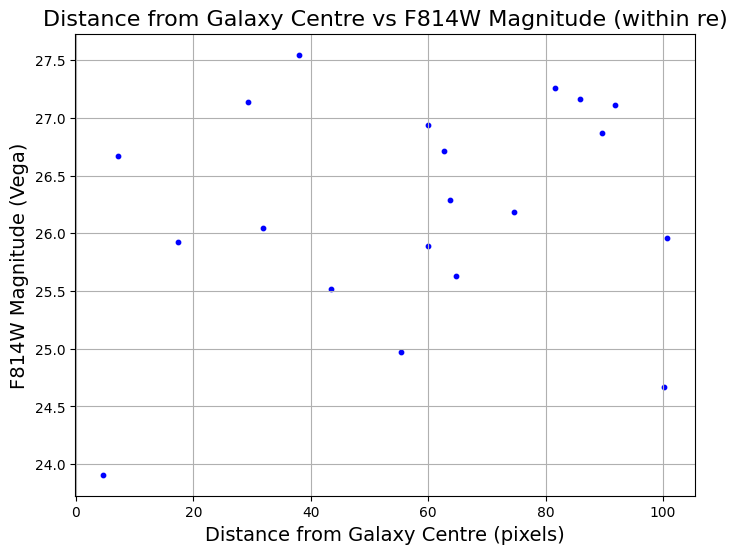

In [14]:
#plotting distance vs magnitude for f814w in re
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f814mag_re55, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

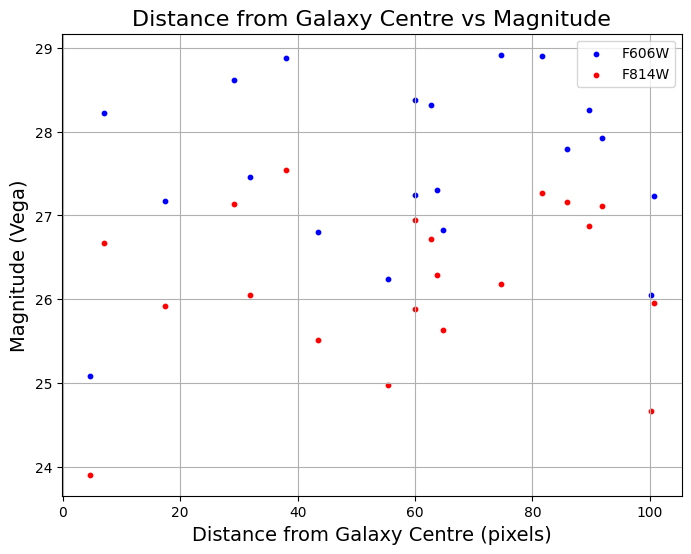

In [15]:
#plotting distance vs magnitude for the objects within re for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal_re55, f606mag_re55, color='blue', s=10, label='F606W')
plt.scatter(distgal_re55, f814mag_re55, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [16]:
# normalising the distance in terms of re
distgal_re55_n = distgal_re55/re_pixels55

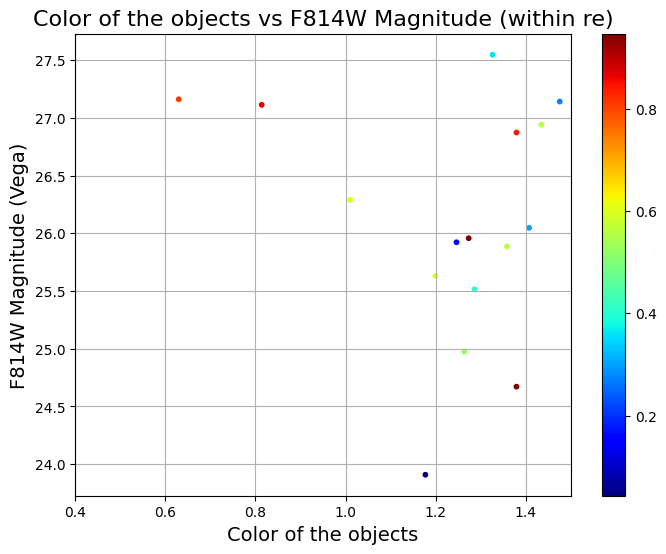

In [17]:
#plotting a color vs magnitude for the objects within a re
plt.figure(figsize=(8,6))

plt.scatter(color55, f814mag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.xlim(0.4, 1.5)
plt.grid()
plt.colorbar()
plt.show()

In [18]:
#Converting into absolute Mag
distgalpc55 = 102.3 * 1e6
absmag_re55 = f814mag_re55 - 5*np.log10(distgalpc55/10)

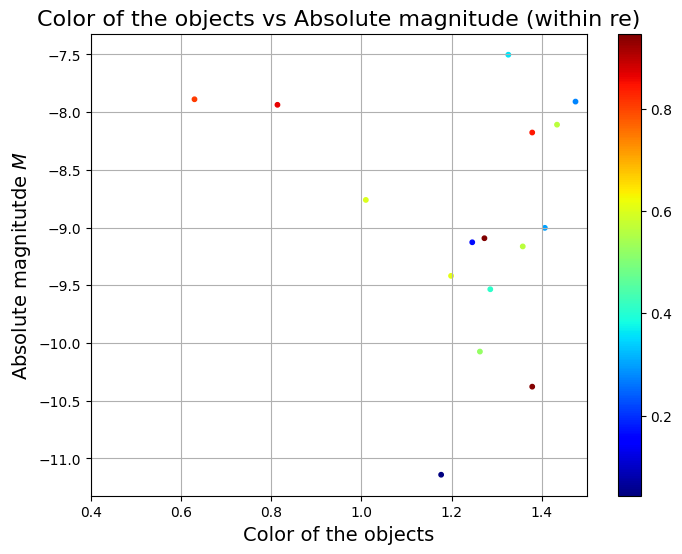

In [34]:
#plotting a color vs absolute magnitude for the objects within a re
plt.figure(figsize=(8,6))
plt.scatter(color55, absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs Absolute magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('Absolute magnitutde $M$', fontsize=14)
plt.xlim(0.4, 1.5)
plt.grid()
plt.colorbar()
plt.show()

In [20]:
#finding the mag of the object in 0.2 re
repixelsp255 = re_pixels55 * 0.2
print(repixelsp255)
f814mag_rep255 = f814mag55[distgal55 <= repixelsp255]

21.28000000000034


In [21]:
#Finding the mag difference of objects in 1 re then 0.2 re
max_mag_diff(f814mag_re55)# 1 re
max_mag_diff(f814mag_rep255)# 0.2 re

 The magnitude difference between the brightest and 2nd brightest object is -0.7629999999999981
 The magnitude difference between the brightest and 2nd brightest object is -2.0139999999999993


In [22]:
# adding concentration index to the catalog
newconcent55 = cut_cat55['newconcent']

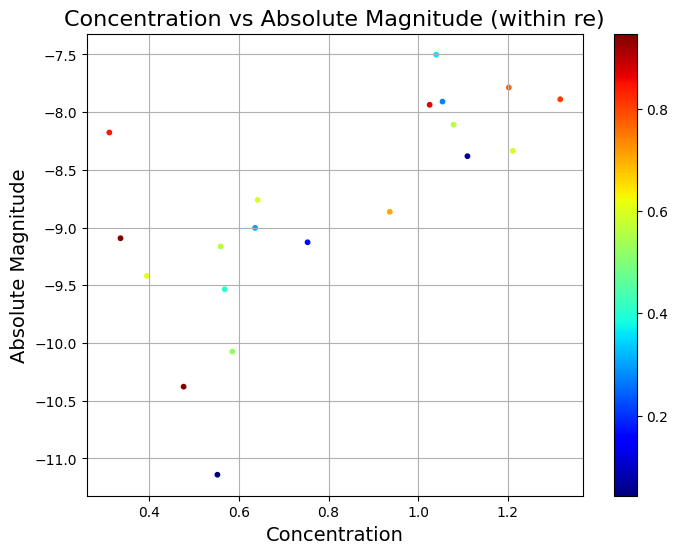

In [23]:
#Plotting the concentration vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent55[distgal55 <= re_pixels55], absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.grid()
plt.colorbar()
plt.show()

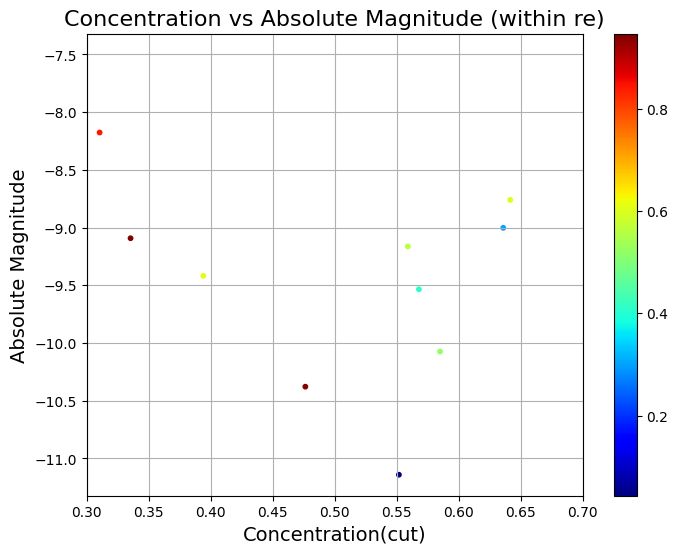

In [24]:
#Plotting the concentration(cut) vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent55[distgal55 <= re_pixels55], absmag_re55, c = distgal_re55_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration(cut)', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.xlim(0.3, 0.7)
plt.grid()
plt.colorbar()
plt.show()

In [25]:
# accessing the fits file to get the header and the wcs information
F814W55 = hdul55[1].data
F814W55header = hdul55[1].header



In [26]:
# Writing code to find the index of the brightest object in 1 re 
minmag55 = 50
for i in range(len(f814mag_re55)):
    if f814mag_re55[i] < minmag55 and distgal_re55_n[i] < 0.2:
        minmag55 = f814mag_re55[i]
        objdist55 = distgal_re55[i]

index55 = 0
for i in range(len(f814mag55)):
    if f814mag55[i] == minmag55:
        index55 = i

print(index55)
print(minmag55)
print(f814mag_re55)
print(distgal_re55)
print(color55)

objxc55 = xcgal55[index55]
objyc55 = ycgal55[index55]
print(index55, minmag55)

129
23.908
[23.908 24.671 24.975 25.515 25.631 25.922 25.886 25.957 26.186 26.047
 26.289 27.161 26.668 26.714 27.113 26.941 26.873 27.141 27.263 27.547]
[  4.64097839 100.16649058  55.39612956  43.52838999  64.73044638
  17.43467505  60.00774653 100.66432126  74.58764489  31.85692371
  63.7847767   85.82724574   7.08858884  62.74172933  91.77174254
  60.02479338  89.69757822  29.23360248  81.55742783  38.02956936]
[1.177 1.379 1.263 1.286 1.199 1.246 1.358 1.273 2.731 1.407 1.01  0.63
 1.557 1.602 0.814 1.434 1.379 1.475 1.641 1.326]
129 23.908


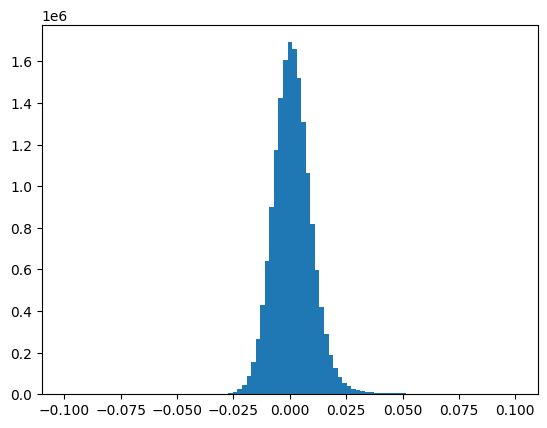

In [27]:
# Checking the distribution of pixel values in the F814W image
plt.hist(F814W55.ravel(),np.linspace(-0.1,0.1, 100))
plt.show()

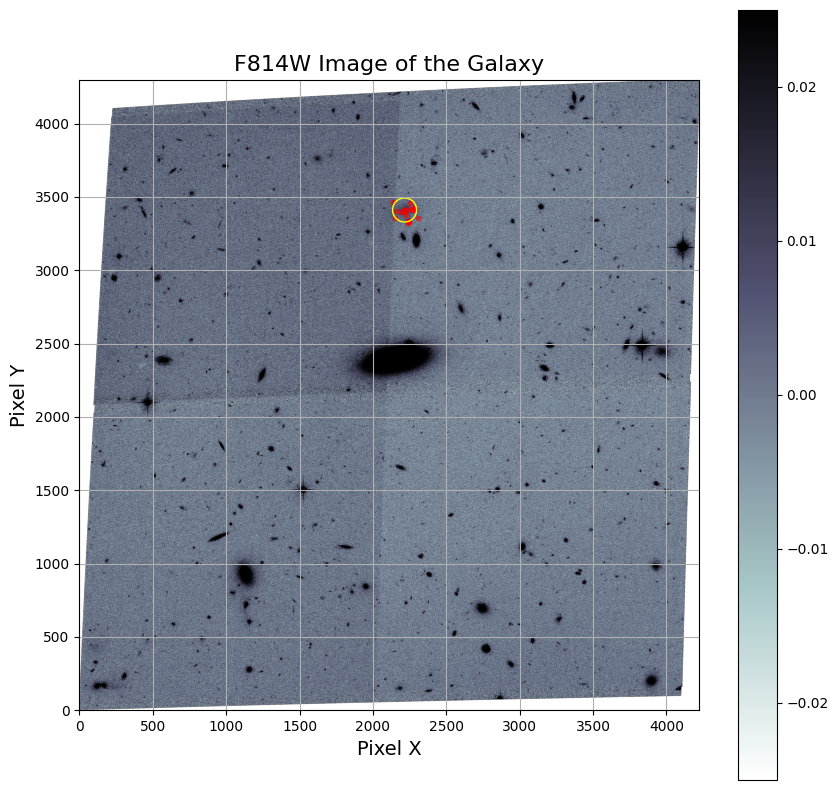

In [35]:
#Plotting the F814W image for the galaxy and overplot all the bright objects within re

fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=10, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('Pixel X', fontsize=14)
plt.ylabel('Pixel Y', fontsize=14)
plt.grid()
plt.show()



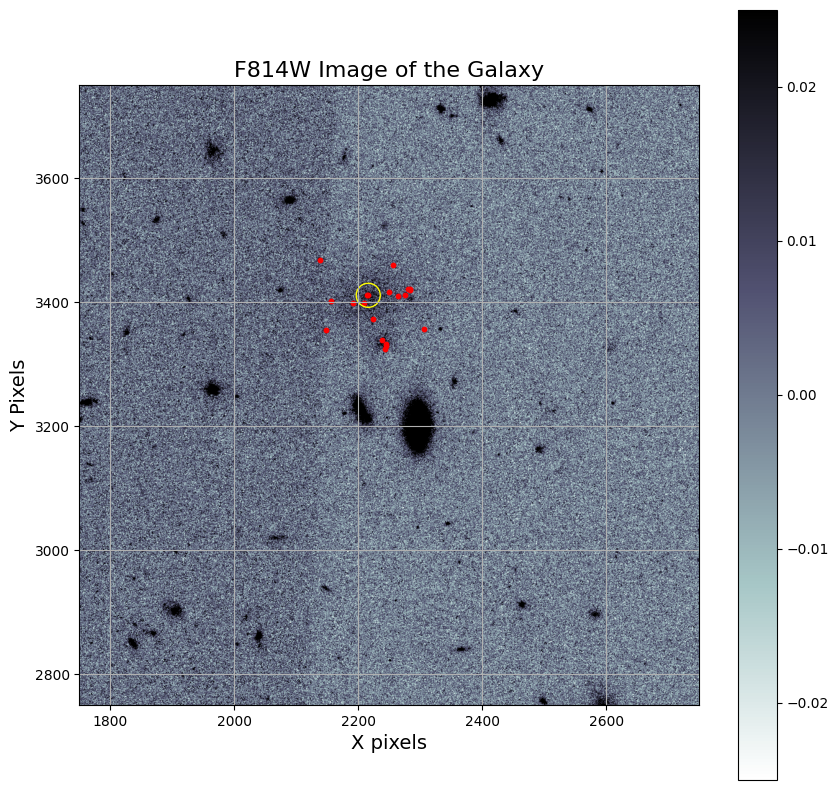

In [36]:
# zooming in for better visualization of the bright objects within re
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=10, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y Pixels', fontsize=14)
plt.xlim(1750, 2750)
plt.ylim(2750, 3750)
plt.grid()
plt.show()

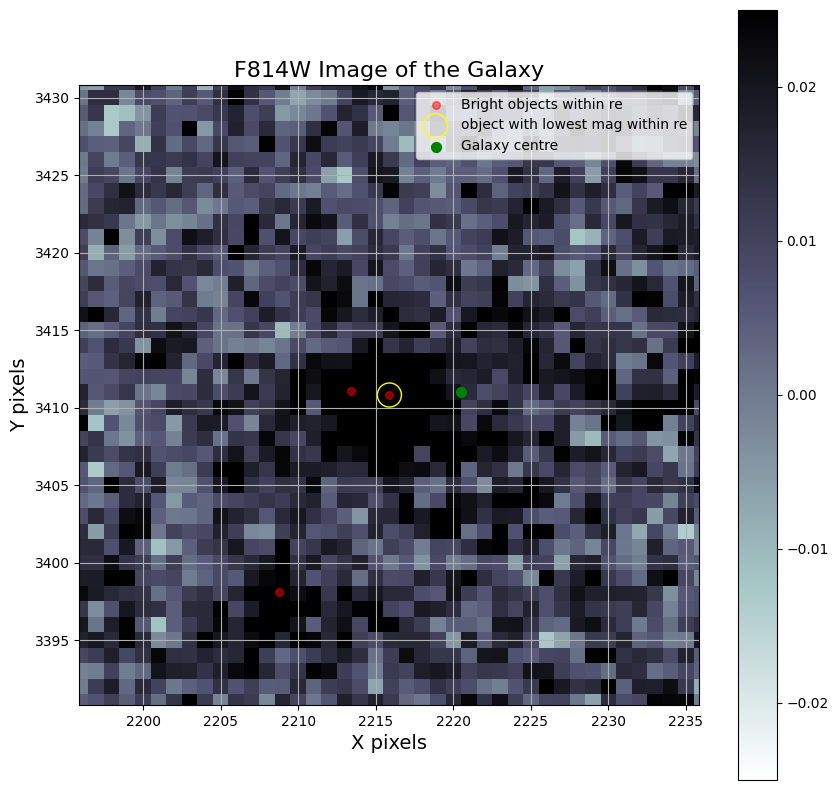

In [37]:
# zooming in even more to see the brightest and closest object to the centre of the galaxy
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y pixels', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

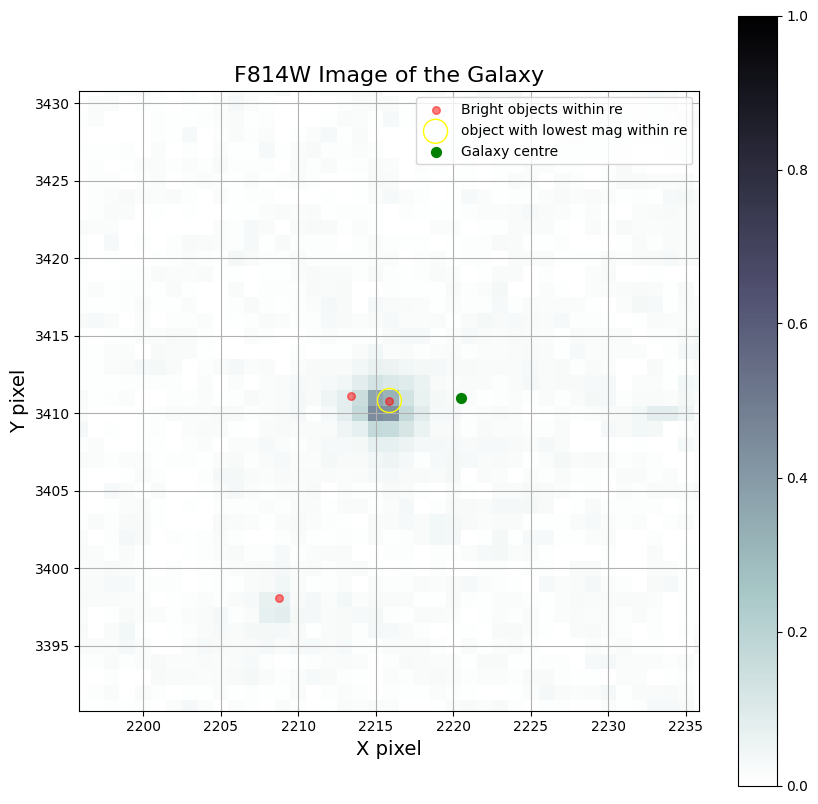

In [38]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = 0, vmax = 1)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

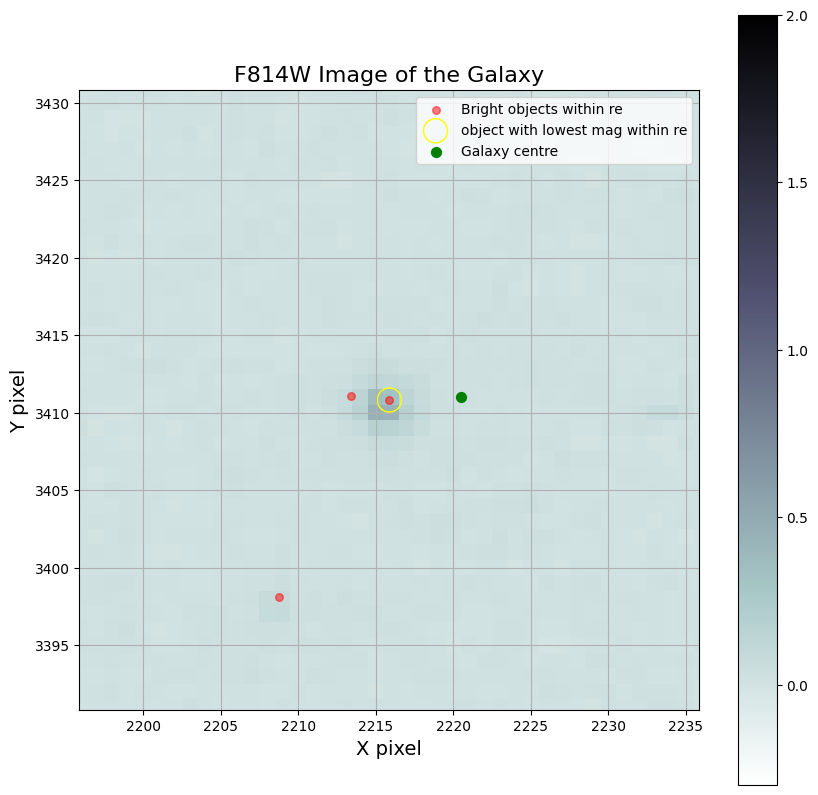

In [39]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-20, objxc55+20)
plt.ylim(objyc55-20, objyc55+20)
plt.legend()
plt.grid()
plt.show()

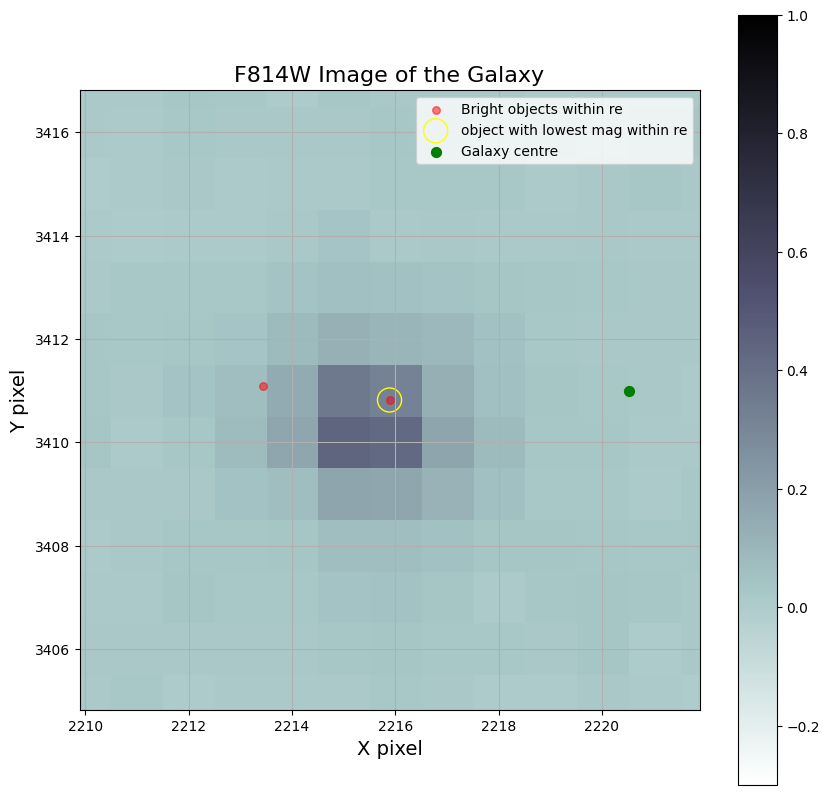

In [40]:
# Zooming in even more
lim = round(objdist55)+1
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W55, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 1)
plt.colorbar()
plt.scatter(xcgal55[distgal55 <= re_pixels55], ycgal55[distgal55 <= re_pixels55], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(objxc55, objyc55, ec = 'yellow', fc = 'none', s=300, alpha = 1, label='object with lowest mag within re')
plt.scatter(galcenx55, galceny55, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(objxc55-lim, objxc55+lim)
plt.ylim(objyc55-lim, objyc55+lim)
plt.legend()
plt.grid()
plt.show()

# Looks like there might be an NSC here